In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/convolve-3-0/Dev_data_to_be_shared.csv
/kaggle/input/convolve-3-0/validation_data_to_be_shared.csv


In [2]:
df=pd.read_csv('/kaggle/input/convolve-3-0/Dev_data_to_be_shared.csv')
df.shape

(96806, 1216)

## ****Exploratory Data Analysis****

In [3]:
df.head()

,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_47,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,onus_attribute_43,onus_attribute_44,onus_attribute_45,onus_attribute_46,onus_attribute_47,onus_attribute_48
0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0,221000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0,25000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0,86000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,215000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.drop(['account_number'],axis=1,inplace=True)

0 : 95434
1 : 1372


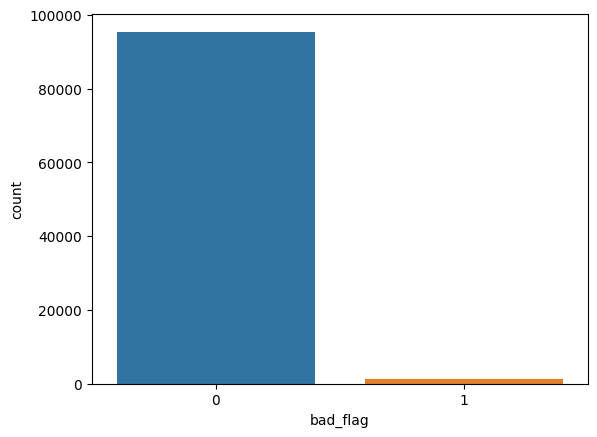

In [5]:
import seaborn as sns
sns.countplot(df, x="bad_flag");
print("0 :",len(df[df['bad_flag']==0]))
print("1 :",len(df[df['bad_flag']==1]))

In [6]:
df_onus_attributes =  df.filter(like='onus_attribute_', axis=1)
df_transaction_attributes = df.filter(like='transaction_attribute_', axis=1)
df_bureau_tradeline_attributes = df.filter(like='bureau_', axis=1)
df_bureau_enquiry_attributes = df.filter(like='bureau_enquiry_', axis=1)

In [7]:
print('Onus-Attributes: ',df_onus_attributes.shape[1])
print('Transaction-Attributes: ',df_transaction_attributes.shape[1])
print('Bureau-Tradeline-Attributes: ',df_bureau_tradeline_attributes.shape[1])
print('Bureau-Enquiry-Attributes: ',df_bureau_enquiry_attributes.shape[1])

Onus-Attributes:  48
Transaction-Attributes:  664
Bureau-Tradeline-Attributes:  502
Bureau-Enquiry-Attributes:  50


In [8]:
drop_cols=[]

## On-us Attributes

In [9]:
df_onus_attributes.columns

Index(['onus_attribute_1', 'onus_attribute_2', 'onus_attribute_3',
       'onus_attribute_4', 'onus_attribute_5', 'onus_attribute_6',
       'onus_attribute_7', 'onus_attribute_8', 'onus_attribute_9',
       'onus_attribute_10', 'onus_attribute_11', 'onus_attribute_12',
       'onus_attribute_13', 'onus_attribute_14', 'onus_attribute_15',
       'onus_attribute_16', 'onus_attribute_17', 'onus_attribute_18',
       'onus_attribute_19', 'onus_attribute_20', 'onus_attribute_21',
       'onus_attribute_22', 'onus_attribute_23', 'onus_attribute_24',
       'onus_attribute_25', 'onus_attribute_26', 'onus_attribute_27',
       'onus_attribute_28', 'onus_attribute_29', 'onus_attribute_30',
       'onus_attribute_31', 'onus_attribute_32', 'onus_attribute_33',
       'onus_attribute_34', 'onus_attribute_35', 'onus_attribute_36',
       'onus_attribute_37', 'onus_attribute_38', 'onus_attribute_39',
       'onus_attribute_40', 'onus_attribute_41', 'onus_attribute_42',
       'onus_attribute_43', '

### ***Percentage of Missing Values***

In [38]:
df_onus_attributes.isnull().sum() / df.shape[0] * 100

onus_attribute_1     26.063467
onus_attribute_2      0.000000
onus_attribute_3      0.000000
onus_attribute_4      0.000000
onus_attribute_5      0.002066
onus_attribute_6     36.839659
onus_attribute_7     46.437204
onus_attribute_8     29.169680
onus_attribute_9     31.435035
onus_attribute_10     0.002066
onus_attribute_11    28.275107
onus_attribute_12    29.733694
onus_attribute_13     0.002066
onus_attribute_14    28.270975
onus_attribute_15    29.724397
onus_attribute_16     0.002066
onus_attribute_17     0.000000
onus_attribute_18     0.000000
onus_attribute_19     0.000000
onus_attribute_20     0.000000
onus_attribute_21     0.000000
onus_attribute_22     0.000000
onus_attribute_23     0.000000
onus_attribute_24     0.000000
onus_attribute_25     0.000000
onus_attribute_26     0.000000
onus_attribute_27     0.000000
onus_attribute_28     0.000000
onus_attribute_29     0.000000
onus_attribute_30     0.000000
onus_attribute_31     0.000000
onus_attribute_32     0.000000
onus_att

#### Dropping Features that have more than 45 percent missing values

In [10]:
drop_cols+=list(df_onus_attributes.isnull().sum()[df_onus_attributes.isnull().sum() / df.shape[0] * 100 > 45].index)
drop_cols

['onus_attribute_7',
 'onus_attribute_43',
 'onus_attribute_44',
 'onus_attribute_45',
 'onus_attribute_46',
 'onus_attribute_47',
 'onus_attribute_48']

In [11]:
df_onus_attributes.drop(df_onus_attributes.isnull().sum()[df_onus_attributes.isnull().sum() / df.shape[0] * 100 > 45].index, axis=1, inplace=True)
df_onus_attributes.isnull().sum() / df.shape[0] * 100

<ipython-input-11-f3c176da050d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_onus_attributes.drop(df_onus_attributes.isnull().sum()[df_onus_attributes.isnull().sum() / df.shape[0] * 100 > 45].index, axis=1, inplace=True)


onus_attribute_1     26.063467
onus_attribute_2      0.000000
onus_attribute_3      0.000000
onus_attribute_4      0.000000
onus_attribute_5      0.002066
onus_attribute_6     36.839659
onus_attribute_8     29.169680
onus_attribute_9     31.435035
onus_attribute_10     0.002066
onus_attribute_11    28.275107
onus_attribute_12    29.733694
onus_attribute_13     0.002066
onus_attribute_14    28.270975
onus_attribute_15    29.724397
onus_attribute_16     0.002066
onus_attribute_17     0.000000
onus_attribute_18     0.000000
onus_attribute_19     0.000000
onus_attribute_20     0.000000
onus_attribute_21     0.000000
onus_attribute_22     0.000000
onus_attribute_23     0.000000
onus_attribute_24     0.000000
onus_attribute_25     0.000000
onus_attribute_26     0.000000
onus_attribute_27     0.000000
onus_attribute_28     0.000000
onus_attribute_29     0.000000
onus_attribute_30     0.000000
onus_attribute_31     0.000000
onus_attribute_32     0.000000
onus_attribute_33     0.000000
onus_att

### ***Coorelation Matrix***

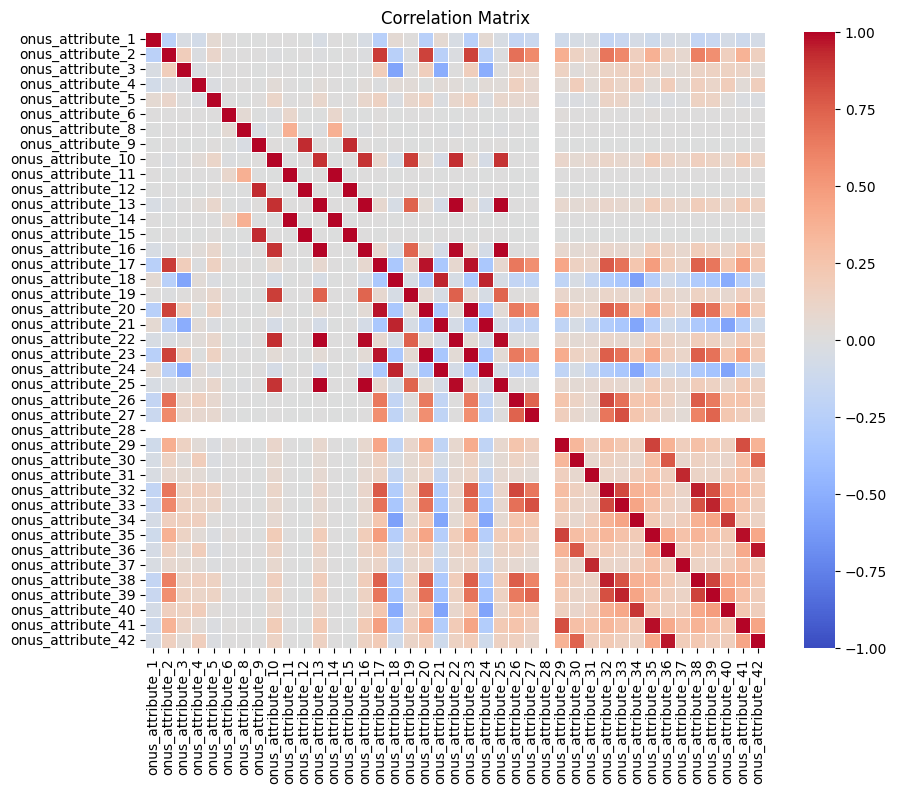

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df_onus_attributes.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

#### Dropping one of the Two Features that have a very high value of Pearson Correlation

In [13]:
corr_matrix = df_onus_attributes.corr().abs()
threshold = 0.9
high_corr_pairs = []

for column in corr_matrix.columns:
    for row in corr_matrix.index:
        if column != row and corr_matrix.loc[row, column] > threshold:
            high_corr_pairs.append((column, row))

features_to_drop = set()
for pair in high_corr_pairs:
    features_to_drop.add(pair[1])
print(f"Dropped features: {features_to_drop}")

Dropped features: {'onus_attribute_21', 'onus_attribute_39', 'onus_attribute_32', 'onus_attribute_25', 'onus_attribute_23', 'onus_attribute_37', 'onus_attribute_12', 'onus_attribute_17', 'onus_attribute_15', 'onus_attribute_38', 'onus_attribute_11', 'onus_attribute_24', 'onus_attribute_33', 'onus_attribute_20', 'onus_attribute_9', 'onus_attribute_31', 'onus_attribute_16', 'onus_attribute_41', 'onus_attribute_42', 'onus_attribute_22', 'onus_attribute_10', 'onus_attribute_13', 'onus_attribute_36', 'onus_attribute_35', 'onus_attribute_18', 'onus_attribute_14'}


In [14]:
drop_cols+=(list(features_to_drop))
drop_cols

['onus_attribute_7',
 'onus_attribute_43',
 'onus_attribute_44',
 'onus_attribute_45',
 'onus_attribute_46',
 'onus_attribute_47',
 'onus_attribute_48',
 'onus_attribute_21',
 'onus_attribute_39',
 'onus_attribute_32',
 'onus_attribute_25',
 'onus_attribute_23',
 'onus_attribute_37',
 'onus_attribute_12',
 'onus_attribute_17',
 'onus_attribute_15',
 'onus_attribute_38',
 'onus_attribute_11',
 'onus_attribute_24',
 'onus_attribute_33',
 'onus_attribute_20',
 'onus_attribute_9',
 'onus_attribute_31',
 'onus_attribute_16',
 'onus_attribute_41',
 'onus_attribute_42',
 'onus_attribute_22',
 'onus_attribute_10',
 'onus_attribute_13',
 'onus_attribute_36',
 'onus_attribute_35',
 'onus_attribute_18',
 'onus_attribute_14']

In [15]:
df_onus_attributes.drop(list(features_to_drop),axis=1,inplace=True)
df_onus_attributes.shape

<ipython-input-15-0ba266c7cefa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_onus_attributes.drop(list(features_to_drop),axis=1,inplace=True)


(96806, 15)

### ***Remaining Features***

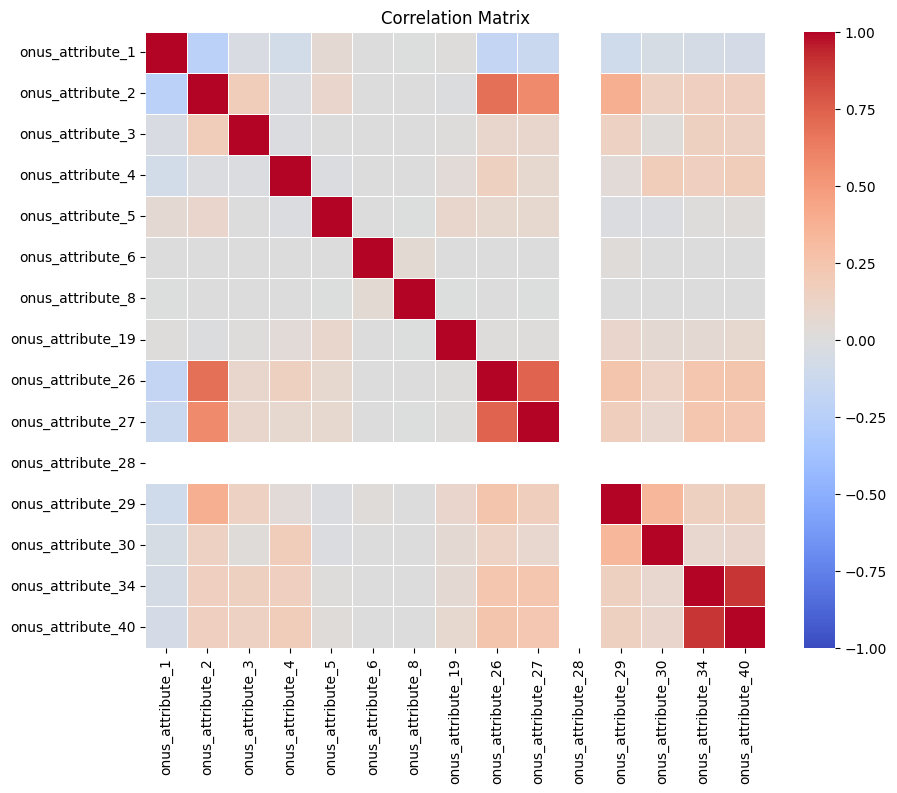

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr_matrix = df_onus_attributes.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

In [17]:
df_onus_attributes.isnull().sum() / df.shape[0] * 100

onus_attribute_1     26.063467
onus_attribute_2      0.000000
onus_attribute_3      0.000000
onus_attribute_4      0.000000
onus_attribute_5      0.002066
onus_attribute_6     36.839659
onus_attribute_8     29.169680
onus_attribute_19     0.000000
onus_attribute_26     0.000000
onus_attribute_27     0.000000
onus_attribute_28     0.000000
onus_attribute_29     0.000000
onus_attribute_30     0.000000
onus_attribute_34     0.000000
onus_attribute_40     0.000000
dtype: float64

#### Analyzing the Missing Values for Imputation

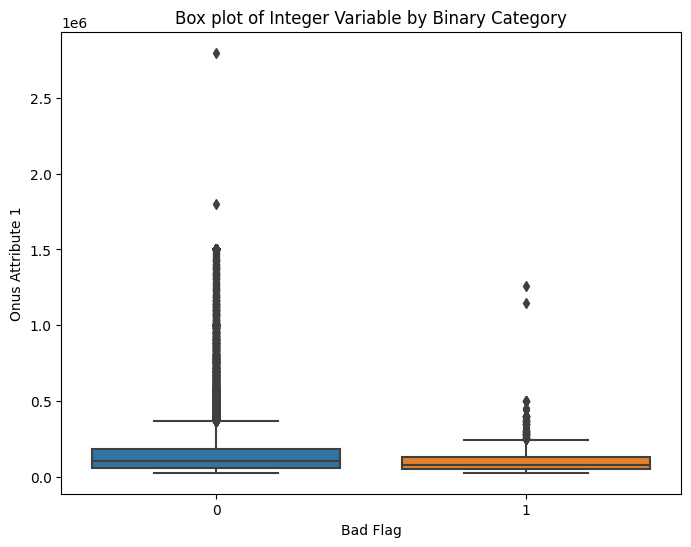

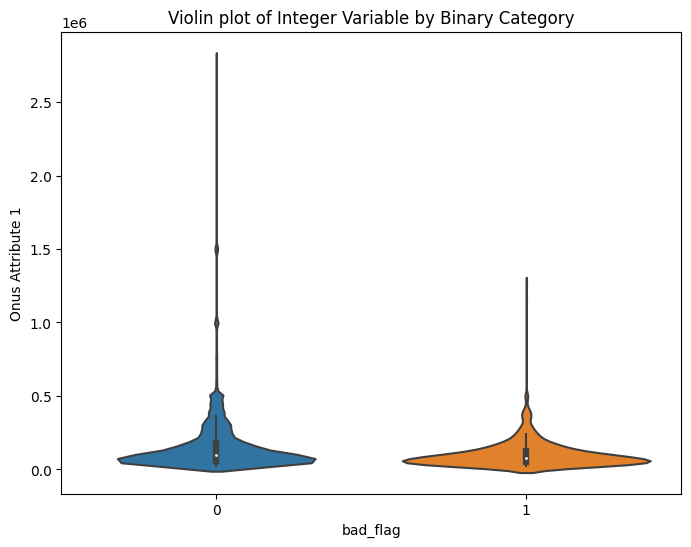

In [18]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['bad_flag'], y=df['onus_attribute_1'])
plt.xlabel('Bad Flag')
plt.ylabel('Onus Attribute 1')
plt.title('Box plot of Integer Variable by Binary Category');


plt.figure(figsize=(8, 6))
sns.violinplot(x=df['bad_flag'], y=df['onus_attribute_1'])
plt.ylabel('Onus Attribute 1')
plt.title('Violin plot of Integer Variable by Binary Category');

In [19]:
df['onus_attribute_1'] = df['onus_attribute_1'].fillna(df['onus_attribute_1'].median())

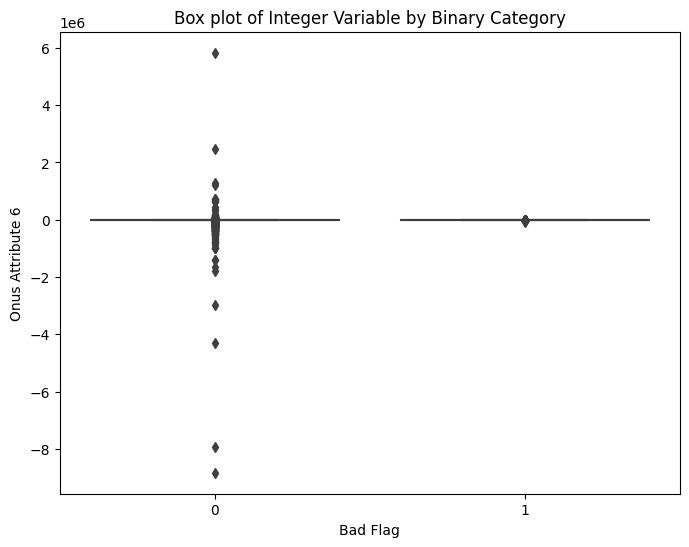

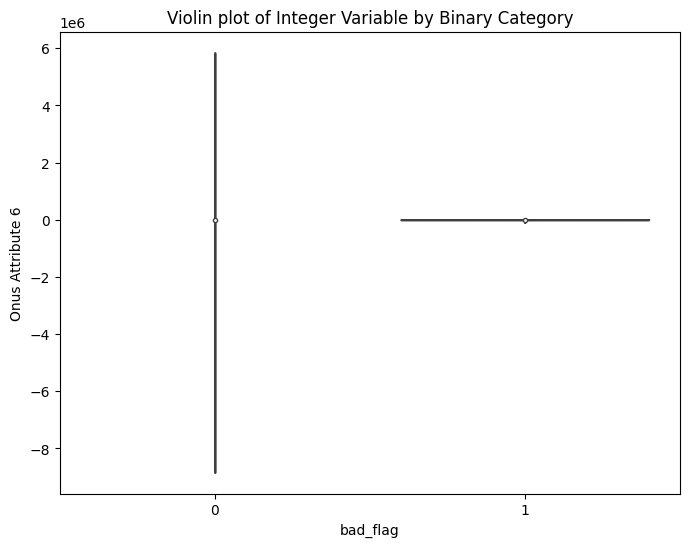

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['bad_flag'], y=df['onus_attribute_6'])
plt.xlabel('Bad Flag')
plt.ylabel('Onus Attribute 6')
plt.title('Box plot of Integer Variable by Binary Category');


plt.figure(figsize=(8, 6))
sns.violinplot(x=df['bad_flag'], y=df['onus_attribute_6'])
plt.ylabel('Onus Attribute 6')
plt.title('Violin plot of Integer Variable by Binary Category');

In [21]:
df['onus_attribute_6'] = df['onus_attribute_6'].fillna(0)

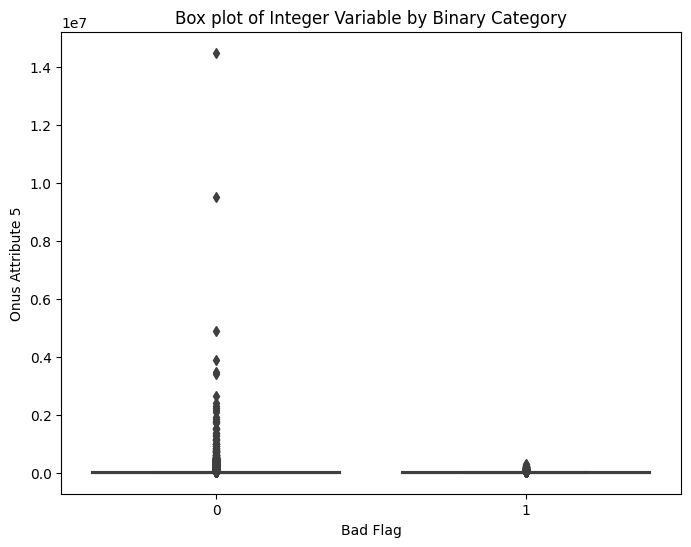

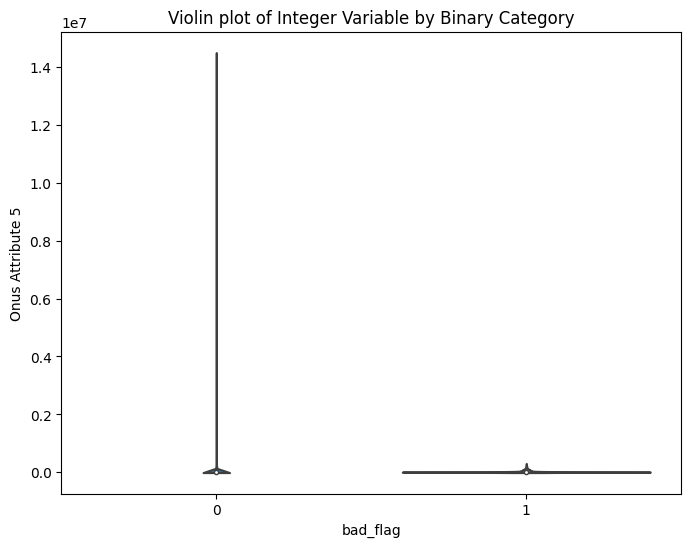

In [22]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['bad_flag'], y=df['onus_attribute_5'])
plt.xlabel('Bad Flag')
plt.ylabel('Onus Attribute 5')
plt.title('Box plot of Integer Variable by Binary Category');


plt.figure(figsize=(8, 6))
sns.violinplot(x=df['bad_flag'], y=df['onus_attribute_5'])
plt.ylabel('Onus Attribute 5')
plt.title('Violin plot of Integer Variable by Binary Category');

/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


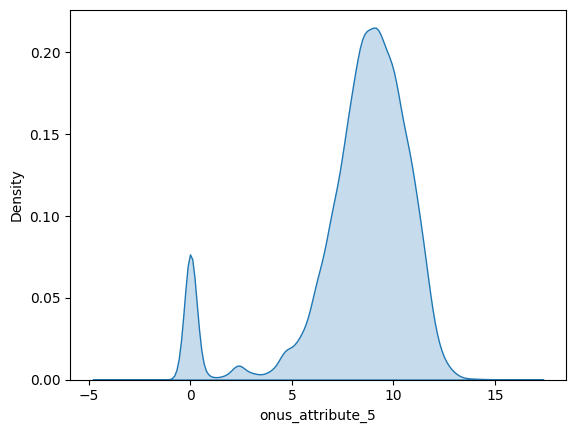

In [23]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
sns.kdeplot(np.log(df['onus_attribute_5']), fill=True);

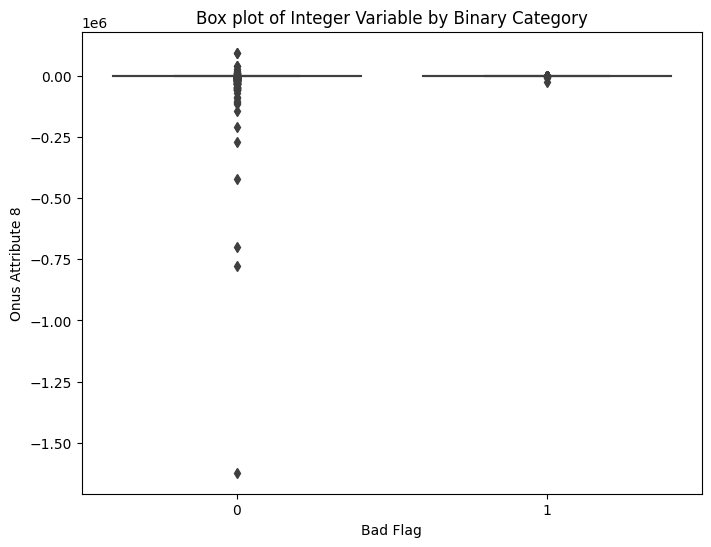

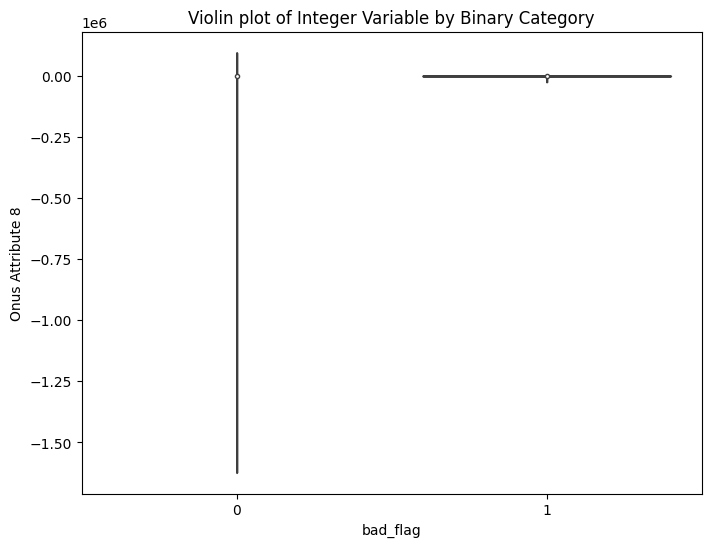

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['bad_flag'], y=df['onus_attribute_8'])
plt.xlabel('Bad Flag')
plt.ylabel('Onus Attribute 8')
plt.title('Box plot of Integer Variable by Binary Category');


plt.figure(figsize=(8, 6))
sns.violinplot(x=df['bad_flag'], y=df['onus_attribute_8'])
plt.ylabel('Onus Attribute 8')
plt.title('Violin plot of Integer Variable by Binary Category');

In [25]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
iterative_imputer = IterativeImputer(max_iter=10, random_state=42)
df_imputed = iterative_imputer.fit_transform(df_onus_attributes)
df_imputed = pd.DataFrame(df_imputed, columns=df_onus_attributes.columns)
df['onus_attribute_8']=df_imputed['onus_attribute_8'].copy()
df['onus_attribute_5']=df_imputed['onus_attribute_5'].copy()

## ****Transaction Attributes****

In [26]:
df_transaction_attributes.shape

(96806, 664)

In [27]:
df_transaction_attributes.isnull().sum() / df.shape[0] * 100

transaction_attribute_1      26.063467
transaction_attribute_2      26.063467
transaction_attribute_3      26.063467
transaction_attribute_4      26.063467
transaction_attribute_5      26.063467
                               ...    
transaction_attribute_660    26.063467
transaction_attribute_661    26.063467
transaction_attribute_662    26.063467
transaction_attribute_663    26.063467
transaction_attribute_664    26.063467
Length: 664, dtype: float64

### ***Pearson Correlation Matrix***

In [28]:
corr_matrix = df_transaction_attributes.corr()

In [29]:
corr_matrix = corr_matrix.abs()
threshold = 0.75
high_corr_pairs = []

for column in corr_matrix.columns:
    for row in corr_matrix.index:
        if column != row and corr_matrix.loc[row, column] > threshold:
            high_corr_pairs.append((column, row))
features_to_drop = set()
for pair in high_corr_pairs:
    features_to_drop.add(pair[1])

print(len(features_to_drop))
print(f"Dropped features: {features_to_drop}")

627
Dropped features: {'transaction_attribute_591', 'transaction_attribute_270', 'transaction_attribute_640', 'transaction_attribute_370', 'transaction_attribute_21', 'transaction_attribute_131', 'transaction_attribute_1', 'transaction_attribute_372', 'transaction_attribute_291', 'transaction_attribute_341', 'transaction_attribute_342', 'transaction_attribute_636', 'transaction_attribute_551', 'transaction_attribute_622', 'transaction_attribute_115', 'transaction_attribute_409', 'transaction_attribute_174', 'transaction_attribute_491', 'transaction_attribute_254', 'transaction_attribute_646', 'transaction_attribute_282', 'transaction_attribute_467', 'transaction_attribute_617', 'transaction_attribute_401', 'transaction_attribute_120', 'transaction_attribute_207', 'transaction_attribute_199', 'transaction_attribute_445', 'transaction_attribute_567', 'transaction_attribute_526', 'transaction_attribute_421', 'transaction_attribute_512', 'transaction_attribute_70', 'transaction_attribute_1

In [30]:
drop_cols+=(list(features_to_drop))

In [31]:
df_transaction_attributes.drop(features_to_drop,axis=1,inplace=True)
df_transaction_attributes.isnull().sum() / df.shape[0] * 100

<ipython-input-31-74b5e9ded368>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_transaction_attributes.drop(features_to_drop,axis=1,inplace=True)


transaction_attribute_38     26.063467
transaction_attribute_65     26.063467
transaction_attribute_83     26.063467
transaction_attribute_119    26.279363
transaction_attribute_124    26.279363
transaction_attribute_128    26.279363
transaction_attribute_132    26.279363
transaction_attribute_145    26.279363
transaction_attribute_148    26.279363
transaction_attribute_152    26.279363
transaction_attribute_184    26.063467
transaction_attribute_191    26.063467
transaction_attribute_264    26.063467
transaction_attribute_359    26.145074
transaction_attribute_404    26.145074
transaction_attribute_414    26.145074
transaction_attribute_424    26.145074
transaction_attribute_429    26.145074
transaction_attribute_489    26.145074
transaction_attribute_504    26.145074
transaction_attribute_514    26.145074
transaction_attribute_524    26.145074
transaction_attribute_525    26.063467
transaction_attribute_539    26.145074
transaction_attribute_547    26.063467
transaction_attribute_549

In [32]:
df_new=df_transaction_attributes.copy()
df_new.dropna(subset=['transaction_attribute_124'],inplace=True)
df_new.isnull().sum() / df.shape[0] * 100

transaction_attribute_38     0.000000
transaction_attribute_65     0.000000
transaction_attribute_83     0.000000
transaction_attribute_119    0.000000
transaction_attribute_124    0.000000
transaction_attribute_128    0.000000
transaction_attribute_132    0.000000
transaction_attribute_145    0.000000
transaction_attribute_148    0.000000
transaction_attribute_152    0.000000
transaction_attribute_184    0.000000
transaction_attribute_191    0.000000
transaction_attribute_264    0.000000
transaction_attribute_359    0.000000
transaction_attribute_404    0.000000
transaction_attribute_414    0.000000
transaction_attribute_424    0.000000
transaction_attribute_429    0.000000
transaction_attribute_489    0.000000
transaction_attribute_504    0.000000
transaction_attribute_514    0.000000
transaction_attribute_524    0.000000
transaction_attribute_525    0.000000
transaction_attribute_539    0.000000
transaction_attribute_547    0.000000
transaction_attribute_549    0.024792
transaction_

In [33]:
df_transaction_attributes.dropna(subset=['transaction_attribute_124'],inplace=True)
df_transaction_attributes.dropna(subset=['transaction_attribute_572'],inplace=True)
df_transaction_attributes.isnull().sum() / df.shape[0] * 100

<ipython-input-33-38dc14919dec>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_transaction_attributes.dropna(subset=['transaction_attribute_124'],inplace=True)
<ipython-input-33-38dc14919dec>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_transaction_attributes.dropna(subset=['transaction_attribute_572'],inplace=True)


transaction_attribute_38     0.0
transaction_attribute_65     0.0
transaction_attribute_83     0.0
transaction_attribute_119    0.0
transaction_attribute_124    0.0
transaction_attribute_128    0.0
transaction_attribute_132    0.0
transaction_attribute_145    0.0
transaction_attribute_148    0.0
transaction_attribute_152    0.0
transaction_attribute_184    0.0
transaction_attribute_191    0.0
transaction_attribute_264    0.0
transaction_attribute_359    0.0
transaction_attribute_404    0.0
transaction_attribute_414    0.0
transaction_attribute_424    0.0
transaction_attribute_429    0.0
transaction_attribute_489    0.0
transaction_attribute_504    0.0
transaction_attribute_514    0.0
transaction_attribute_524    0.0
transaction_attribute_525    0.0
transaction_attribute_539    0.0
transaction_attribute_547    0.0
transaction_attribute_549    0.0
transaction_attribute_554    0.0
transaction_attribute_560    0.0
transaction_attribute_566    0.0
transaction_attribute_570    0.0
transactio

In [34]:
df.dropna(subset=['transaction_attribute_124'],inplace=True)
df.dropna(subset=['transaction_attribute_572'],inplace=True)

## ****Bureau Tradeline Attributes****

In [35]:
df_bureau_tradeline_attributes.shape

(96806, 502)

In [36]:
df_bureau_tradeline_attributes.isnull().sum() / df_bureau_tradeline_attributes.shape[0] * 100

bureau_1             1.232362
bureau_2             1.232362
bureau_3             1.232362
bureau_4             1.232362
bureau_5             1.232362
                       ...   
bureau_enquiry_46    2.679586
bureau_enquiry_47    2.679586
bureau_enquiry_48    2.679586
bureau_enquiry_49    2.679586
bureau_enquiry_50    2.679586
Length: 502, dtype: float64

In [37]:
drop_cols+=list(df_bureau_tradeline_attributes.isnull().sum()[df_bureau_tradeline_attributes.isnull().sum() / df.shape[0] * 100 > 40].index)
drop_cols

['onus_attribute_7',
 'onus_attribute_43',
 'onus_attribute_44',
 'onus_attribute_45',
 'onus_attribute_46',
 'onus_attribute_47',
 'onus_attribute_48',
 'onus_attribute_21',
 'onus_attribute_39',
 'onus_attribute_32',
 'onus_attribute_25',
 'onus_attribute_23',
 'onus_attribute_37',
 'onus_attribute_12',
 'onus_attribute_17',
 'onus_attribute_15',
 'onus_attribute_38',
 'onus_attribute_11',
 'onus_attribute_24',
 'onus_attribute_33',
 'onus_attribute_20',
 'onus_attribute_9',
 'onus_attribute_31',
 'onus_attribute_16',
 'onus_attribute_41',
 'onus_attribute_42',
 'onus_attribute_22',
 'onus_attribute_10',
 'onus_attribute_13',
 'onus_attribute_36',
 'onus_attribute_35',
 'onus_attribute_18',
 'onus_attribute_14',
 'transaction_attribute_591',
 'transaction_attribute_270',
 'transaction_attribute_640',
 'transaction_attribute_370',
 'transaction_attribute_21',
 'transaction_attribute_131',
 'transaction_attribute_1',
 'transaction_attribute_372',
 'transaction_attribute_291',
 'transac

In [38]:
df_bureau_tradeline_attributes.drop(df_bureau_tradeline_attributes.isnull().sum()[df_bureau_tradeline_attributes.isnull().sum() / df.shape[0] * 100 > 40].index, axis=1, inplace=True)
df_bureau_tradeline_attributes.isnull().sum() / df.shape[0] * 100

<ipython-input-38-1d5e081db5ed>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bureau_tradeline_attributes.drop(df_bureau_tradeline_attributes.isnull().sum()[df_bureau_tradeline_attributes.isnull().sum() / df.shape[0] * 100 > 40].index, axis=1, inplace=True)


bureau_1             1.672227
bureau_2             1.672227
bureau_3             1.672227
bureau_4             1.672227
bureau_5             1.672227
                       ...   
bureau_enquiry_46    3.636007
bureau_enquiry_47    3.636007
bureau_enquiry_48    3.636007
bureau_enquiry_49    3.636007
bureau_enquiry_50    3.636007
Length: 486, dtype: float64

In [39]:
corr_matrix = df_bureau_tradeline_attributes.corr()

In [40]:
corr_matrix = corr_matrix.abs()
threshold = 0.7
high_corr_pairs = []

for column in corr_matrix.columns:
    for row in corr_matrix.index:
        if column != row and corr_matrix.loc[row, column] > threshold:
            high_corr_pairs.append((column, row))
features_to_drop = set()
for pair in high_corr_pairs:
    features_to_drop.add(pair[1])

print(len(features_to_drop))
print(f"Dropped features: {features_to_drop}")

408
Dropped features: {'bureau_159', 'bureau_238', 'bureau_264', 'bureau_enquiry_13', 'bureau_383', 'bureau_354', 'bureau_306', 'bureau_305', 'bureau_enquiry_25', 'bureau_335', 'bureau_376', 'bureau_304', 'bureau_388', 'bureau_enquiry_26', 'bureau_102', 'bureau_241', 'bureau_273', 'bureau_295', 'bureau_331', 'bureau_187', 'bureau_216', 'bureau_1', 'bureau_313', 'bureau_339', 'bureau_278', 'bureau_226', 'bureau_117', 'bureau_113', 'bureau_439', 'bureau_289', 'bureau_enquiry_38', 'bureau_191', 'bureau_7', 'bureau_277', 'bureau_378', 'bureau_enquiry_33', 'bureau_165', 'bureau_170', 'bureau_250', 'bureau_432', 'bureau_enquiry_6', 'bureau_93', 'bureau_345', 'bureau_enquiry_21', 'bureau_430', 'bureau_enquiry_41', 'bureau_156', 'bureau_287', 'bureau_161', 'bureau_enquiry_49', 'bureau_393', 'bureau_225', 'bureau_88', 'bureau_422', 'bureau_52', 'bureau_enquiry_12', 'bureau_20', 'bureau_294', 'bureau_185', 'bureau_213', 'bureau_399', 'bureau_enquiry_4', 'bureau_53', 'bureau_39', 'bureau_126', 'b

In [41]:
drop_cols+=(list(features_to_drop))

In [42]:
df_bureau_tradeline_attributes.drop(features_to_drop,axis=1,inplace=True)
df_bureau_tradeline_attributes.isnull().sum() / df_bureau_tradeline_attributes.shape[0] * 100

<ipython-input-42-50e7d8f7c70e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bureau_tradeline_attributes.drop(features_to_drop,axis=1,inplace=True)


bureau_4             1.232362
bureau_16            1.232362
bureau_26            1.232362
bureau_38            1.232362
bureau_40            1.233395
                       ...   
bureau_enquiry_8     2.679586
bureau_enquiry_17    2.679586
bureau_enquiry_27    2.679586
bureau_enquiry_37    2.679586
bureau_enquiry_47    2.679586
Length: 78, dtype: float64

### Using Iterative imputer for the Reamaining Missing Values

In [43]:
iterative_imputer = IterativeImputer(max_iter=10, random_state=42)
df_imputed = iterative_imputer.fit_transform(df_bureau_tradeline_attributes)
df_imputed = pd.DataFrame(df_imputed, columns=df_bureau_tradeline_attributes.columns)
df[df_bureau_tradeline_attributes.columns]=df_imputed[df_bureau_tradeline_attributes.columns].copy()

Shape Initially

In [44]:
df.shape

(71342, 1215)

Shape After Feature Selection

In [45]:
df.drop(drop_cols,axis=1,inplace=True)
df.shape

(71342, 131)

### ***Current Distribution***

0 : 70294
1 : 1048


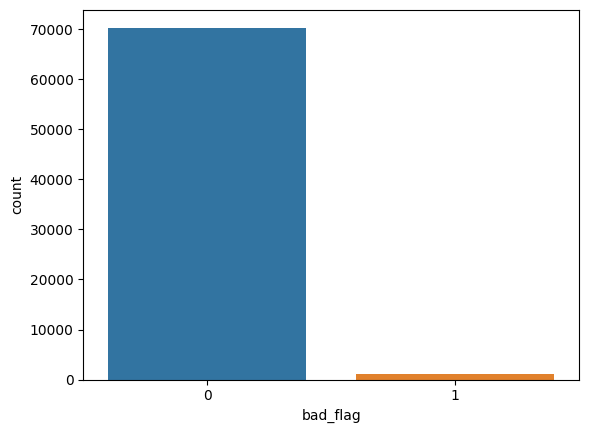

In [46]:
sns.countplot(df, x="bad_flag");
print("0 :",len(df[df['bad_flag']==0]))
print("1 :",len(df[df['bad_flag']==1]))

In [47]:
df.columns

Index(['bad_flag', 'onus_attribute_1', 'transaction_attribute_38',
       'transaction_attribute_65', 'transaction_attribute_83',
       'transaction_attribute_119', 'transaction_attribute_124',
       'transaction_attribute_128', 'transaction_attribute_132',
       'transaction_attribute_145',
       ...
       'onus_attribute_29', 'onus_attribute_30', 'onus_attribute_34',
       'onus_attribute_40', 'bureau_enquiry_7', 'bureau_enquiry_8',
       'bureau_enquiry_17', 'bureau_enquiry_27', 'bureau_enquiry_37',
       'bureau_enquiry_47'],
      dtype='object', length=131)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71342 entries, 1 to 96805
Columns: 131 entries, bad_flag to bureau_enquiry_47
dtypes: float64(120), int64(11)
memory usage: 71.8 MB


#### Converting the data types to their lesser precision versions as we don't need that precise values for our prediction

In [49]:
df1=df.select_dtypes(include=['float64'])
df2=df.select_dtypes(include=['int64'])
df[df1.columns] = df[df1.columns].astype('float32')
df[df2.columns] = df[df2.columns].astype('int32')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71342 entries, 1 to 96805
Columns: 131 entries, bad_flag to bureau_enquiry_47
dtypes: float32(120), int32(11)
memory usage: 36.2 MB


### ***Checking if all the Missing Values have either been Imputed or Removed***

In [50]:
df.isnull().sum() / df.shape[0] * 100

bad_flag                    0.0
onus_attribute_1            0.0
transaction_attribute_38    0.0
transaction_attribute_65    0.0
transaction_attribute_83    0.0
                           ... 
bureau_enquiry_8            0.0
bureau_enquiry_17           0.0
bureau_enquiry_27           0.0
bureau_enquiry_37           0.0
bureau_enquiry_47           0.0
Length: 131, dtype: float64

In [51]:
from sklearn.metrics import log_loss, f1_score, roc_auc_score, confusion_matrix
import numpy as np

def gmean(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    return np.sqrt(sensitivity * specificity)

def custom_metric(y_true, y_pred_probs, weights=(0.35, 0.30, 0.25, 0.10)):
    y_pred = (y_pred_probs >= 0.5).astype(int)
    auc_roc = roc_auc_score(y_true, y_pred_probs)
    f1 = f1_score(y_true, y_pred)
    gmean_score = gmean(y_true, y_pred)
    logloss = log_loss(y_true, y_pred_probs)
    score = (weights[0] * auc_roc) + (weights[1] * f1) + (weights[2] * gmean_score) - (weights[3] * logloss)
    return score

## Base-Model

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, log_loss, roc_auc_score

X = df.drop(columns=['bad_flag'])
y = df['bad_flag']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

log_loss_value = log_loss(y_test, y_pred_prob)
print(f"\nLog Loss: {log_loss_value:.4f}")
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred_prob[:,1])
print(f"ROC AUC Score: {roc_auc}")

print(f"IAS Score: {custom_metric(y_test, y_pred_prob[:,1])}")

Accuracy: 0.9847

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     14050
           1       0.00      0.00      0.00       219

    accuracy                           0.98     14269
   macro avg       0.49      0.50      0.50     14269
weighted avg       0.97      0.98      0.98     14269


Log Loss: 0.1735
ROC AUC Score: 0.6881241164139813
IAS Score: 0.22349058625079765


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [53]:
from sklearn.ensemble import AdaBoostClassifier
clf = AdaBoostClassifier(n_estimators=100, random_state=0)
clf.fit(X_train, y_train)
y_pred=clf.predict(X_test)
y_pred_prob = clf.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
log_loss_value = log_loss(y_test, y_pred_prob)
print(f"\nLog Loss: {log_loss_value:.4f}")
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred_prob[:,1])
print(f"ROC AUC Score: {roc_auc}")
print(f"IAS Score: {custom_metric(y_test, y_pred_prob[:,1])}")

Accuracy: 0.9847

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     14050
           1       0.50      0.00      0.01       219

    accuracy                           0.98     14269
   macro avg       0.74      0.50      0.50     14269
weighted avg       0.98      0.98      0.98     14269


Log Loss: 0.6622
ROC AUC Score: 0.7681873283608768
IAS Score: 0.22225708933282678



### Indentifying the Categorical Features for Label Encoding

In [54]:
categorical_columns = df.columns[df.nunique() < 30].tolist()
print(categorical_columns)

['bad_flag', 'transaction_attribute_38', 'transaction_attribute_65', 'transaction_attribute_83', 'transaction_attribute_152', 'transaction_attribute_191', 'transaction_attribute_524', 'transaction_attribute_525', 'transaction_attribute_582', 'transaction_attribute_621', 'bureau_4', 'bureau_16', 'bureau_26', 'bureau_38', 'bureau_47', 'bureau_56', 'bureau_67', 'bureau_68', 'bureau_69', 'bureau_70', 'bureau_71', 'bureau_73', 'bureau_77', 'bureau_79', 'bureau_80', 'bureau_81', 'bureau_90', 'bureau_91', 'bureau_100', 'bureau_110', 'bureau_120', 'bureau_131', 'bureau_142', 'bureau_152', 'bureau_162', 'bureau_172', 'bureau_179', 'bureau_181', 'bureau_182', 'bureau_184', 'bureau_186', 'bureau_192', 'bureau_202', 'bureau_212', 'bureau_222', 'bureau_232', 'bureau_242', 'bureau_252', 'bureau_262', 'bureau_272', 'bureau_282', 'bureau_292', 'bureau_302', 'bureau_312', 'bureau_322', 'bureau_332', 'bureau_342', 'bureau_352', 'bureau_362', 'bureau_372', 'bureau_382', 'bureau_392', 'bureau_402', 'burea

## Loading in the Test Dataset to encode it's features along with the train dataset

In [55]:
df_test=pd.read_csv('/kaggle/input/convolve-3-0/validation_data_to_be_shared.csv')
df_test = df_test[df.columns[1:]]
df_test.shape

(41792, 130)

### ***Percentage of Missing Values***

In [56]:
df_test.isnull().sum() / df_test.shape[0] * 100

onus_attribute_1             26.296899
transaction_attribute_38     26.296899
transaction_attribute_65     26.296899
transaction_attribute_83     26.296899
transaction_attribute_119    26.490716
                               ...    
bureau_enquiry_8              2.696688
bureau_enquiry_17             2.696688
bureau_enquiry_27             2.696688
bureau_enquiry_37             2.696688
bureau_enquiry_47             2.696688
Length: 130, dtype: float64

In [57]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41792 entries, 0 to 41791
Columns: 130 entries, onus_attribute_1 to bureau_enquiry_47
dtypes: float64(120), int64(10)
memory usage: 41.5 MB


In [58]:
df1=df_test.select_dtypes(include=['float64'])
df2=df_test.select_dtypes(include=['int64'])
df_test[df1.columns] = df_test[df1.columns].astype('float32')
df_test[df2.columns] = df_test[df2.columns].astype('int32')
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41792 entries, 0 to 41791
Columns: 130 entries, onus_attribute_1 to bureau_enquiry_47
dtypes: float32(120), int32(10)
memory usage: 20.7 MB


### ***Using Iterative Imputer with High Number of Iterations for Precise Imputation of the test Dataset***

In [59]:
iterative_imputer = IterativeImputer(max_iter=50, random_state=42)
df_imputed = iterative_imputer.fit_transform(df_test)
df_test = pd.DataFrame(df_imputed, columns=df_test.columns)

In [60]:
df_test.shape

(41792, 130)

In [61]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for col in categorical_columns[1:]:
    df[col] = label_encoder.fit_transform(df[col])
    df_test[col] = df_test[col].apply(lambda x: label_encoder.transform([x])[0] if x in label_encoder.classes_ else 0)

In [62]:
import tensorflow as tf
import tensorflow_decision_forests as tfdf

print(f"Found TF-DF {tfdf.__version__}")

Found TF-DF 1.10.0


In [63]:
numerical_columns = [col for col in df.columns.tolist() if col not in categorical_columns]

In [64]:
df_test.columns

Index(['onus_attribute_1', 'transaction_attribute_38',
       'transaction_attribute_65', 'transaction_attribute_83',
       'transaction_attribute_119', 'transaction_attribute_124',
       'transaction_attribute_128', 'transaction_attribute_132',
       'transaction_attribute_145', 'transaction_attribute_148',
       ...
       'onus_attribute_29', 'onus_attribute_30', 'onus_attribute_34',
       'onus_attribute_40', 'bureau_enquiry_7', 'bureau_enquiry_8',
       'bureau_enquiry_17', 'bureau_enquiry_27', 'bureau_enquiry_37',
       'bureau_enquiry_47'],
      dtype='object', length=130)

In [66]:
dff=pd.read_csv('/kaggle/input/convolve-3-0/validation_data_to_be_shared.csv')
account_numbers=dff['account_number']
account_numbers.shape

(41792,)

### ***Feature Scaling: Z-Score Normalization***

In [67]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
df_test[numerical_columns] = scaler.transform(df_test[numerical_columns]) 

### ***Splitting X and y while keeping the distribution same using 'stratify=y'***

In [68]:
X = df.drop(columns=['bad_flag'])
y = df['bad_flag']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.1, random_state=42)

### Imbalance-Aware Score (IAS)

The **Imbalance-Aware Score (IAS)** is a custom metric designed to evaluate model performance in imbalanced classification tasks. It incorporates various classification metrics to address the challenges posed by highly imbalanced datasets. IAS is a weighted combination of the following:

- **AUC-ROC (α)**: Measures the model's ability to distinguish between classes.
- **F1-Score (β)**: Balances precision and recall, particularly useful for imbalanced classes.
- **G-Mean (γ)**: Evaluates the balance between sensitivity and specificity.
- **Log Loss (δ)**: Penalizes the model for large discrepancies between predicted probabilities and true labels.

#### Formula for IAS:

$$
IAS = \alpha \times \text{AUC-ROC} + \beta \times \text{F1-Score} + \gamma \times \text{G-Mean} - \delta \times \text{Log Loss}
$$

Where:
- **α = 0.35**, **β = 0.30**, **γ = 0.25**, and **δ = 0.10** are the weights assigned to each metric.
- The constants **α**, **β**, **γ**, and **δ** are chosen to balance the importance of each metric based on the goals of the imbalanced classification problem.

A higher IAS indicates better model performance in handling class imbalances.

### ***Gradient-Boosted Decision Forest(GBDF) without Oversampling***

In [71]:
from sklearn.metrics import f1_score

train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(df,label="bad_flag")
model = tfdf.keras.GradientBoostedTreesModel(
    verbose=0,
    features=[tfdf.keras.FeatureUsage(name=n) for n in X.columns],
    exclude_non_specified_features=True,
    random_seed=1234,
)
model.fit(train_ds)

self_evaluation = model.make_inspector().evaluation()
print(f"Accuracy: {self_evaluation.accuracy} Loss:{self_evaluation.loss}")

serving_ds=tfdf.keras.pd_dataframe_to_tf_dataset(X_test)
proba_survive = model.predict(serving_ds, verbose=0)[:,0]
roc_auc = roc_auc_score(y_test, proba_survive)
print(f"ROC AUC Score: {roc_auc}")
threshold = 0.5
y_pred = [1 if prob >= threshold else 0 for prob in proba_survive]
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)
print(f"IAS Score: {custom_metric(y_test, proba_survive)}")

Accuracy: 0.9857754707336426 Loss:0.1276368349790573
ROC AUC Score: 0.9006015037593985
F1 Score: 0.14035087719298248
IAS Score: 0.42103107453776306


### ***Borderline-SMOTE + GBDF***

In [72]:
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split

X = df.drop(columns=['bad_flag'])
y = df['bad_flag']
smote = BorderlineSMOTE(random_state=42, kind="borderline-1")
X_resampled, y_resampled = smote.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [73]:
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(df,label="bad_flag")
serving_ds=tfdf.keras.pd_dataframe_to_tf_dataset(X_test)
model = tfdf.keras.GradientBoostedTreesModel(
    verbose=0, # Very few logs
    features=[tfdf.keras.FeatureUsage(name=n) for n in X.columns],
    exclude_non_specified_features=True,
    random_seed=1234,
)
model.fit(train_ds)

self_evaluation = model.make_inspector().evaluation()
print(f"Accuracy: {self_evaluation.accuracy} Loss:{self_evaluation.loss}")
proba_survive = model.predict(serving_ds, verbose=0)[:,0]
roc_auc = roc_auc_score(y_test, proba_survive)
print(f"ROC AUC Score: {roc_auc}")

Accuracy: 0.9857754707336426 Loss:0.1276368349790573
ROC AUC Score: 0.9065458523120801


In [74]:
threshold = 0.5
y_pred = [1 if prob >= threshold else 0 for prob in proba_survive]
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)
print(f"IAS Score: {custom_metric(y_test, proba_survive)}")

F1 Score: 0.0651220180970661
IAS Score: 0.22956335559307287


### ***Random OverSampler + GBDF***

In [75]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

train_df = pd.DataFrame(X_train, columns=X.columns)
train_df["bad_flag"] = y_train
test_df = pd.DataFrame(X_test, columns=X.columns)
test_df["bad_flag"] = y_test

train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_df,label="bad_flag")
serving_ds=tfdf.keras.pd_dataframe_to_tf_dataset(test_df, label="bad_flag")
model = tfdf.keras.GradientBoostedTreesModel(
    verbose=0, # Very few logs
    features=[tfdf.keras.FeatureUsage(name=n) for n in X.columns],
    exclude_non_specified_features=True, # Only use the features in "features"
    random_seed=1234,
)
model.fit(train_ds)

self_evaluation = model.make_inspector().evaluation()
print(f"Accuracy: {self_evaluation.accuracy} Loss:{self_evaluation.loss}")
proba_survive = model.predict(serving_ds, verbose=0)[:,0]
roc_auc = roc_auc_score(y_test, proba_survive)
print(f"ROC AUC Score: {roc_auc}")

<ipython-input-75-1ec615a8d8e4>:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["bad_flag"] = y_train
<ipython-input-75-1ec615a8d8e4>:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["bad_flag"] = y_test


Accuracy: 0.9207322597503662 Loss:0.5324130058288574
ROC AUC Score: 0.9767297504584203


In [76]:
threshold = 0.5
y_pred = [1 if prob >= threshold else 0 for prob in proba_survive]
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)
print(f"IAS Score: {custom_metric(y_test, proba_survive)}")

F1 Score: 0.9280048604313633
IAS Score: 0.8245485593716948


### ***SMOTE + GBDF***

In [77]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

train_df = pd.DataFrame(X_train, columns=X.columns)
train_df["bad_flag"] = y_train
test_df = pd.DataFrame(X_test, columns=X.columns)
test_df["bad_flag"] = y_test

train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_df,label="bad_flag")
serving_ds=tfdf.keras.pd_dataframe_to_tf_dataset(test_df, label="bad_flag")
model = tfdf.keras.GradientBoostedTreesModel(
    verbose=0, # Very few logs
    features=[tfdf.keras.FeatureUsage(name=n) for n in X.columns],
    exclude_non_specified_features=True, # Only use the features in "features"
    random_seed=1234,
)
model.fit(train_ds)

self_evaluation = model.make_inspector().evaluation()
print(f"Accuracy: {self_evaluation.accuracy} Loss:{self_evaluation.loss}")
proba_survive = model.predict(serving_ds, verbose=0)[:,0]
roc_auc = roc_auc_score(y_test, proba_survive)
print(f"ROC AUC Score: {roc_auc}")

<ipython-input-77-328a9fd3b1e5>:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["bad_flag"] = y_train
<ipython-input-77-328a9fd3b1e5>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["bad_flag"] = y_test


Accuracy: 0.9433040022850037 Loss:0.3440696597099304
ROC AUC Score: 0.9871509300921568


In [78]:
threshold = 0.5
y_pred = [1 if prob >= threshold else 0 for prob in proba_survive]
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)
print(f"IAS Score: {custom_metric(y_test, proba_survive)}")

F1 Score: 0.9444972371801639
IAS Score: 0.8478978474031481


### ***ADASYN + GBDF***

In [79]:
from imblearn.over_sampling import ADASYN

# Apply ADASYN
adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

train_df = pd.DataFrame(X_train, columns=X.columns)
train_df["bad_flag"] = y_train
test_df = pd.DataFrame(X_test, columns=X.columns)
test_df["bad_flag"] = y_test

train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_df,label="bad_flag")
serving_ds=tfdf.keras.pd_dataframe_to_tf_dataset(test_df, label="bad_flag")
model = tfdf.keras.GradientBoostedTreesModel(
    verbose=0, # Very few logs
    features=[tfdf.keras.FeatureUsage(name=n) for n in X.columns],
    exclude_non_specified_features=True, # Only use the features in "features"
    random_seed=1234,
)
model.fit(train_ds)

self_evaluation = model.make_inspector().evaluation()
print(f"Accuracy: {self_evaluation.accuracy} Loss:{self_evaluation.loss}")
proba_survive = model.predict(serving_ds, verbose=0)[:,0]
roc_auc = roc_auc_score(y_test, proba_survive)
print(f"ROC AUC Score: {roc_auc}")

<ipython-input-79-4b22bca2af0a>:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["bad_flag"] = y_train
<ipython-input-79-4b22bca2af0a>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["bad_flag"] = y_test


Accuracy: 0.9431625604629517 Loss:0.34254029393196106
ROC AUC Score: 0.9872316506074735


In [80]:
threshold = 0.5
y_pred = [1 if prob >= threshold else 0 for prob in proba_survive]
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)
print(f"IAS Score: {custom_metric(y_test, proba_survive)}")

F1 Score: 0.9440698417204912
IAS Score: 0.8477647543597524


### ***SMOTE-Tomek + GBDF***

In [81]:
from imblearn.combine import SMOTETomek

# Apply SMOTE + Tomek Links
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

train_df = pd.DataFrame(X_train, columns=X.columns)
train_df["bad_flag"] = y_train
test_df = pd.DataFrame(X_test, columns=X.columns)
test_df["bad_flag"] = y_test

train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_df,label="bad_flag")
serving_ds=tfdf.keras.pd_dataframe_to_tf_dataset(test_df, label="bad_flag")
model = tfdf.keras.GradientBoostedTreesModel(
    verbose=0, # Very few logs
    features=[tfdf.keras.FeatureUsage(name=n) for n in X.columns],
    exclude_non_specified_features=True, # Only use the features in "features"
    random_seed=1234,
)
model.fit(train_ds)

self_evaluation = model.make_inspector().evaluation()
print(f"Accuracy: {self_evaluation.accuracy} Loss:{self_evaluation.loss}")
proba_survive = model.predict(serving_ds, verbose=0)[:,0]
roc_auc = roc_auc_score(y_test, proba_survive)
print(f"ROC AUC Score: {roc_auc}")

<ipython-input-81-99ba49b2fad2>:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["bad_flag"] = y_train
<ipython-input-81-99ba49b2fad2>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["bad_flag"] = y_test


Accuracy: 0.9435103535652161 Loss:0.3452862501144409
ROC AUC Score: 0.9869271619089929


In [82]:
threshold = 0.5
y_pred = [1 if prob >= threshold else 0 for prob in proba_survive]
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)
print(f"IAS Score: {custom_metric(y_test, proba_survive)}")

F1 Score: 0.9447239742045214
IAS Score: 0.8480160961402913


### ***SMOTE-NC + GBDF***

In [83]:
from imblearn.over_sampling import SMOTENC

smote_nc = SMOTENC(categorical_features=[0, 2], random_state=42)
X_resampled, y_resampled = smote_nc.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

train_df = pd.DataFrame(X_train, columns=X.columns)
train_df["bad_flag"] = y_train
test_df = pd.DataFrame(X_test, columns=X.columns)
test_df["bad_flag"] = y_test

train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_df,label="bad_flag")
serving_ds=tfdf.keras.pd_dataframe_to_tf_dataset(test_df, label="bad_flag")
model = tfdf.keras.GradientBoostedTreesModel(
    verbose=0, # Very few logs
    features=[tfdf.keras.FeatureUsage(name=n) for n in X.columns],
    exclude_non_specified_features=True, # Only use the features in "features"
    random_seed=1234,
)
model.fit(train_ds)

self_evaluation = model.make_inspector().evaluation()
print(f"Accuracy: {self_evaluation.accuracy} Loss:{self_evaluation.loss}")
proba_survive = model.predict(serving_ds, verbose=0)[:,0]
roc_auc = roc_auc_score(y_test, proba_survive)
print(f"ROC AUC Score: {roc_auc}")

<ipython-input-83-634f89309592>:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["bad_flag"] = y_train
<ipython-input-83-634f89309592>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["bad_flag"] = y_test


Accuracy: 0.9569003582000732 Loss:0.2765847146511078
ROC AUC Score: 0.9924243725882947


In [85]:
threshold = 0.5
y_pred = [1 if prob >= threshold else 0 for prob in proba_survive]
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)
print(f"IAS Score: {custom_metric(y_test, proba_survive)}")

F1 Score: 0.9583998297691243
IAS Score: 0.8610735706796291


### ***Cluster-Centroids + GBDF***

In [86]:
from imblearn.under_sampling import ClusterCentroids

# Apply ClusterCentroids
cc = ClusterCentroids(random_state=42)
X_resampled, y_resampled = cc.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

train_df = pd.DataFrame(X_train, columns=X.columns)
train_df["bad_flag"] = y_train
test_df = pd.DataFrame(X_test, columns=X.columns)
test_df["bad_flag"] = y_test

train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_df,label="bad_flag")
serving_ds=tfdf.keras.pd_dataframe_to_tf_dataset(test_df, label="bad_flag")
model = tfdf.keras.GradientBoostedTreesModel(
    verbose=0, # Very few logs
    features=[tfdf.keras.FeatureUsage(name=n) for n in X.columns],
    exclude_non_specified_features=True, # Only use the features in "features"
    random_seed=1234,
)
model.fit(train_ds)

self_evaluation = model.make_inspector().evaluation()
print(f"Accuracy: {self_evaluation.accuracy} Loss:{self_evaluation.loss}")
proba_survive = model.predict(serving_ds, verbose=0)[:,0]
roc_auc = roc_auc_score(y_test, proba_survive)
print(f"ROC AUC Score: {roc_auc}")

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
<ipython-input-86-74770cae8ef8>:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["bad_flag"] = y_train
<ipython-input-86-74770cae8ef8>:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["bad_flag"] = y_test


Accuracy: 0.9682539701461792 Loss:0.1499660313129425
ROC AUC Score: 0.9977072030146876


In [87]:
threshold = 0.5
y_pred = [1 if prob >= threshold else 0 for prob in proba_survive]
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)
print(f"IAS Score: {custom_metric(y_test, proba_survive)}")

F1 Score: 0.9615384615384616
IAS Score: 0.8705061207883561


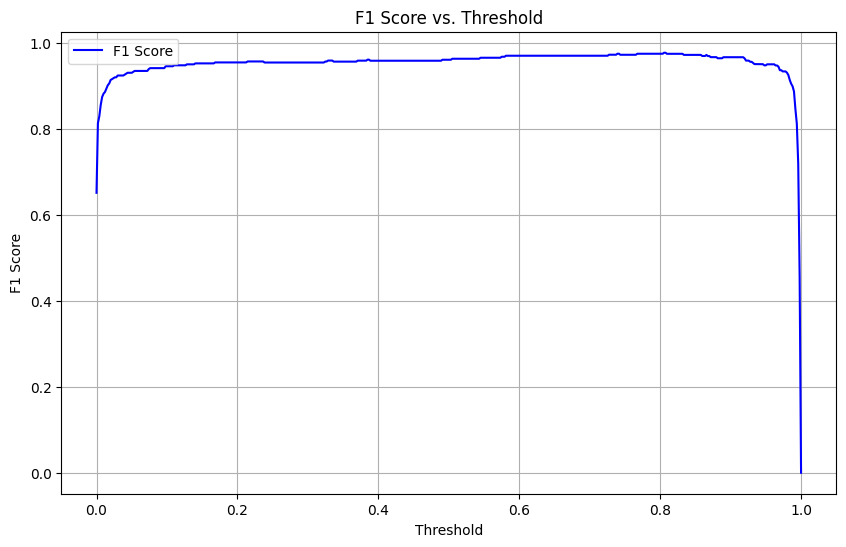

In [88]:
thresholds = np.linspace(0, 1, 500)
f1_scores = []

for threshold in thresholds:
    y_pred = [1 if prob >= threshold else 0 for prob in proba_survive]
    f1_scores.append(f1_score(y_test, y_pred))

# Plot F1 score vs. threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, color='b', label="F1 Score")
plt.title("F1 Score vs. Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.grid()
plt.legend()
plt.show()

## ***Checking If our model performs well on different Imbalance Ratio's***

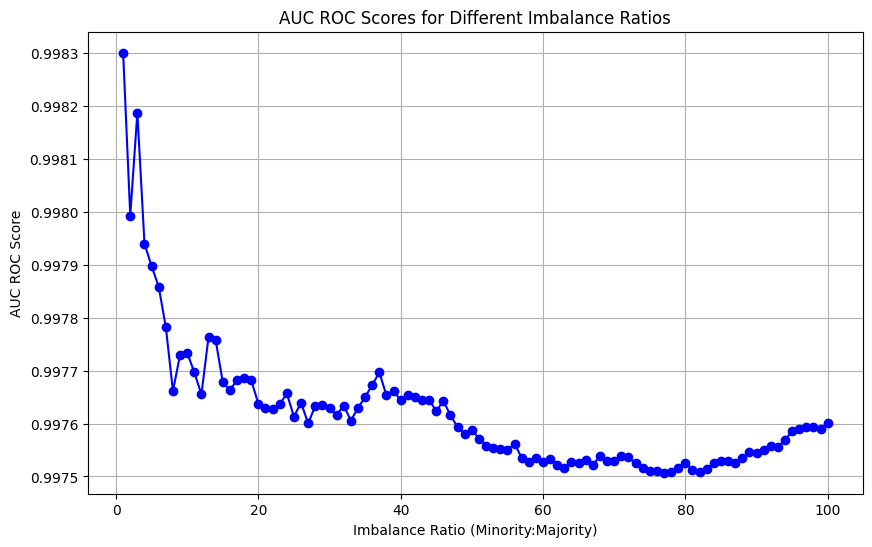

In [89]:
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

def calculate_auc_for_imbalance_ratios(X_test, y_test, model, max_ratio=100):
    auc_scores = []
    ratios = range(1, max_ratio + 1)

    for ratio in ratios:
        majority_class = y_test == 0
        minority_class = y_test == 1
        majority_samples = X_test[majority_class]
        minority_samples = X_test[minority_class]
        resampled_minority = resample(minority_samples, 
                                      replace=True, 
                                      n_samples=len(majority_samples) * ratio, 
                                      random_state=42)
        X_resampled = np.concatenate([majority_samples, resampled_minority])
        y_resampled = np.concatenate([y_test[majority_class], np.ones(len(resampled_minority))])
        resampled_df = pd.DataFrame(X_resampled, columns=X_test.columns)
        resampled_df["bad_flag"] = y_resampled
        resampled_ds = tfdf.keras.pd_dataframe_to_tf_dataset(resampled_df, label="bad_flag")
        proba_survive = model.predict(resampled_ds, verbose=0)[:,0]
        auc = roc_auc_score(y_resampled, proba_survive)
        auc_scores.append(auc)

    return ratios, auc_scores

ratios, auc_scores = calculate_auc_for_imbalance_ratios(X_test, y_test, model)
plt.figure(figsize=(10, 6))
plt.plot(ratios, auc_scores, marker='o', linestyle='-', color='b')
plt.title('AUC ROC Scores for Different Imbalance Ratios')
plt.xlabel('Imbalance Ratio (Minority:Majority)')
plt.ylabel('AUC ROC Score')
plt.grid(True);

## ***Comparative Graphs***

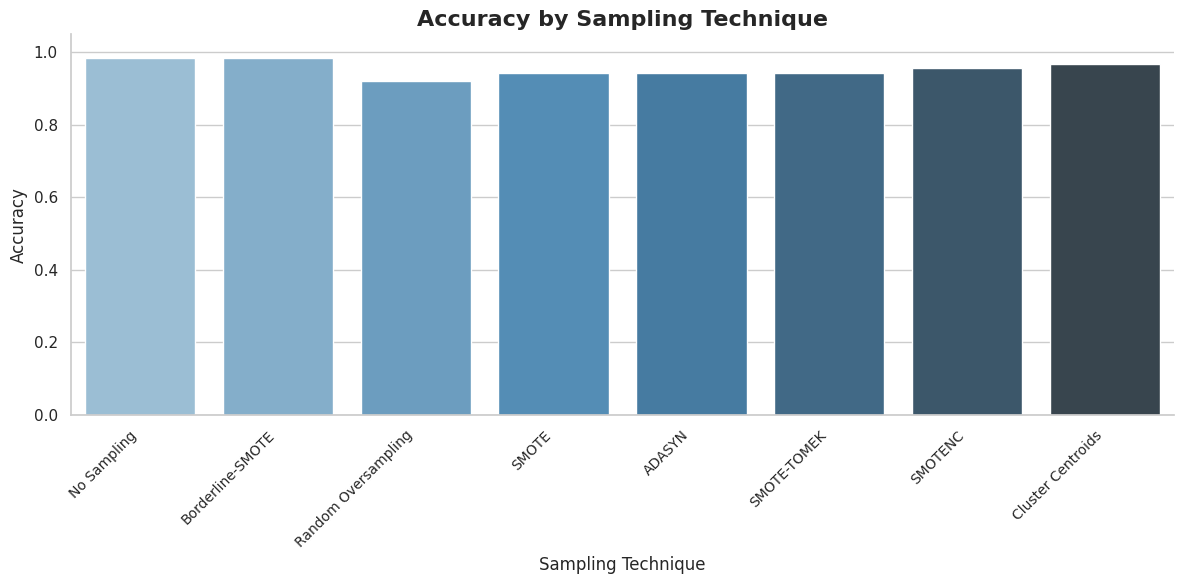

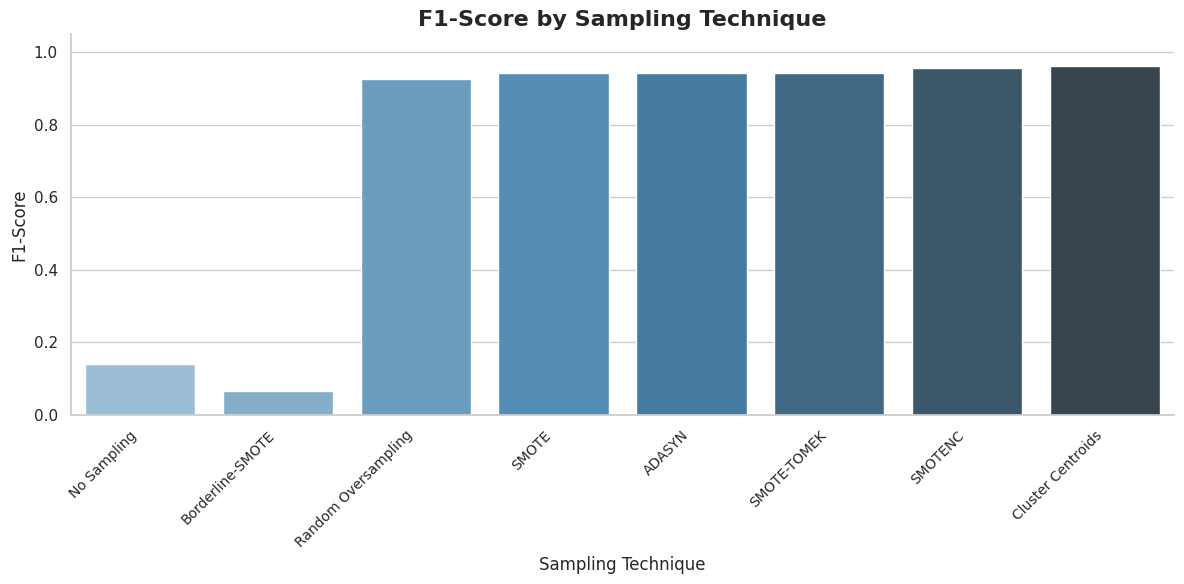

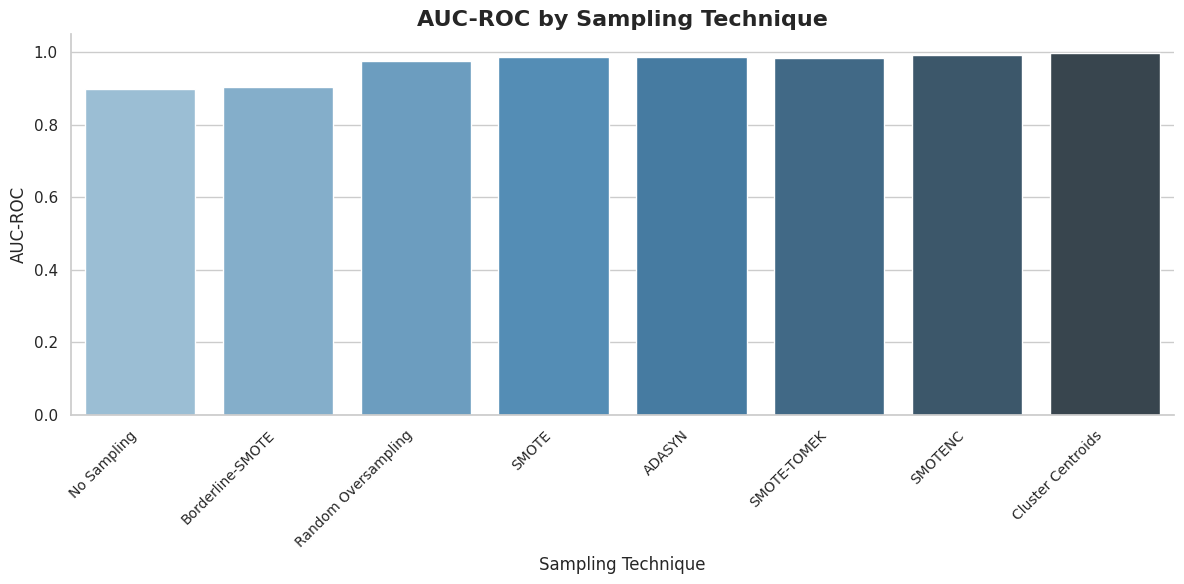

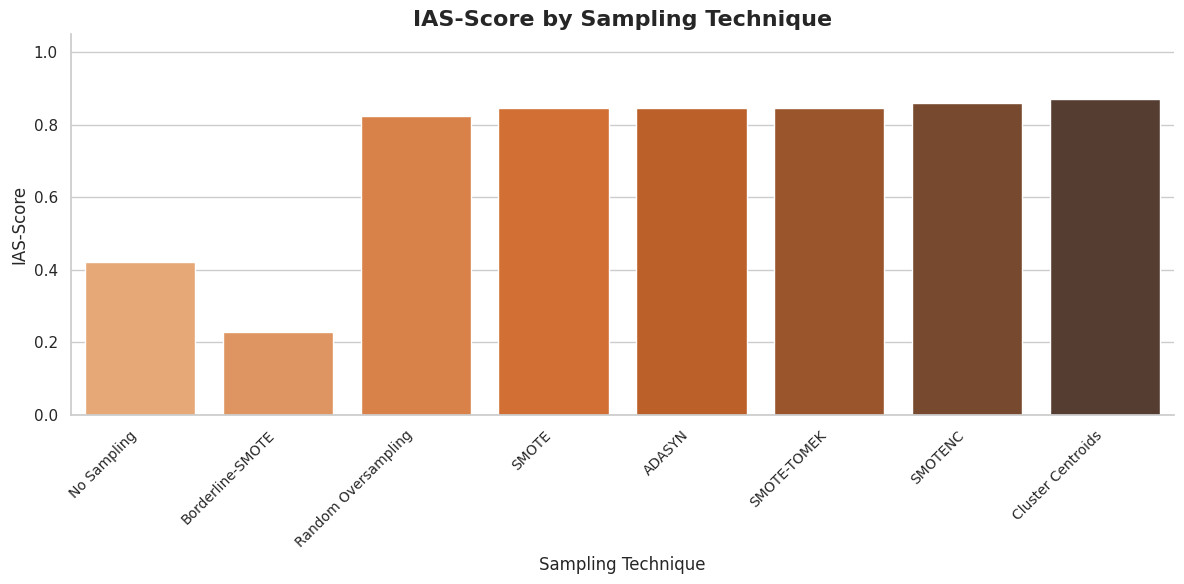

In [114]:
data = {
    "Sampling Technique": [
        "No Sampling", "Borderline-SMOTE", "Random Oversampling", 
        "SMOTE", "ADASYN", "SMOTE-TOMEK", "SMOTENC", "Cluster Centroids"
    ],
    "Accuracy": [0.985, 0.985, 0.920, 0.943, 0.943, 0.943, 0.956, 0.968],
    "F1-Score": [0.140, 0.065, 0.928, 0.944, 0.944, 0.944, 0.958, 0.962],
    "AUC-ROC": [0.900, 0.906, 0.976, 0.987, 0.987, 0.986, 0.992, 0.998],
    "IAS-Score": [0.421, 0.229, 0.824, 0.848, 0.847, 0.848, 0.861, 0.871],
}
df = pd.DataFrame(data)
sns.set_theme(style="whitegrid", palette="pastel")
metrics = ["Accuracy", "F1-Score", "AUC-ROC", "IAS-Score"]

for metric in metrics:
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df,
        x="Sampling Technique",
        y=metric,
        palette="Blues_d" if metric != "IAS-Score" else "Oranges_d"
    )
    plt.title(f"{metric} by Sampling Technique", fontsize=16, fontweight="bold")
    plt.xlabel("Sampling Technique", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.ylim(0, 1.05)
    sns.despine()
    plt.tight_layout()
    plt.show()

### ***Feature Importances Plot for ClusterCentroids + GBDF***

In [104]:
inspector = model.make_inspector()
feature_importances = inspector.variable_importances()["SUM_SCORE"]
print(feature_importances)


[("transaction_attribute_429" (1; #109), 779.2733124862002), ("transaction_attribute_424" (1; #108), 255.98777599375308), ("transaction_attribute_586" (1; #127), 99.04331286382444), ("bureau_146" (1; #18), 75.95801382491618), ("onus_attribute_6" (1; #92), 65.71350892862051), ("onus_attribute_2" (1; #81), 62.81179127830546), ("onus_attribute_8" (1; #93), 57.69967388310715), ("transaction_attribute_404" (1; #106), 49.34713588614159), ("transaction_attribute_489" (1; #110), 43.47856157526621), ("onus_attribute_5" (1; #91), 41.130801143308645), ("transaction_attribute_547" (1; #116), 40.68563118369616), ("onus_attribute_26" (1; #82), 35.70544103656084), ("transaction_attribute_554" (1; #118), 35.70366114301942), ("onus_attribute_29" (1; #85), 32.49463644108528), ("bureau_443" (1; #58), 30.823091503618343), ("onus_attribute_4" (1; #89), 30.189375596086848), ("bureau_410" (1; #55), 27.74783909396092), ("transaction_attribute_514" (1; #112), 24.55439064512234), ("bureau_135" (1; #10), 23.4389

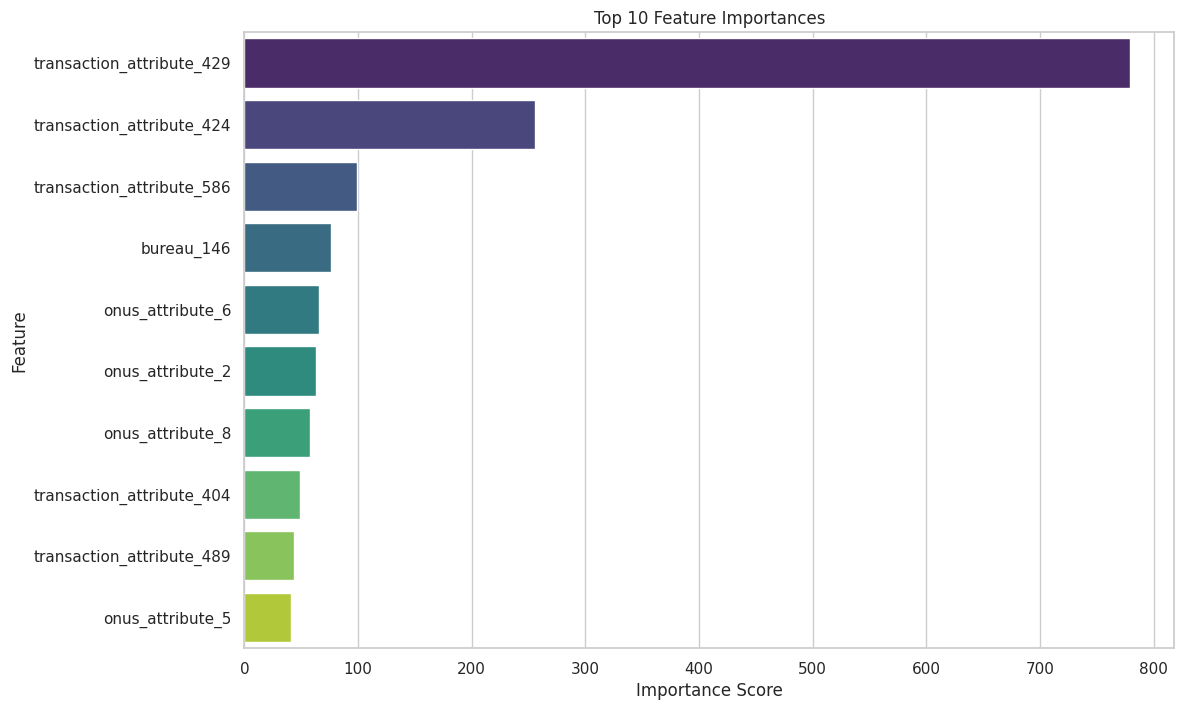

In [105]:
feature_importances = [
    ("transaction_attribute_429", 779.2733124862002),
    ("transaction_attribute_424", 255.98777599375308),
    ("transaction_attribute_586", 99.04331286382444),
    ("bureau_146", 75.95801382491618),
    ("onus_attribute_6", 65.71350892862051),
    ("onus_attribute_2", 62.81179127830546),
    ("onus_attribute_8", 57.69967388310715),
    ("transaction_attribute_404", 49.34713588614159),
    ("transaction_attribute_489", 43.47856157526621),
    ("onus_attribute_5", 41.130801143308645),
    ("transaction_attribute_547", 40.68563118369616),
    ("onus_attribute_26", 35.70544103656084),
    ("transaction_attribute_554", 35.70366114301942),
    ("onus_attribute_29", 32.49463644108528),
    ("bureau_443", 30.823091503618343),
    ("onus_attribute_4", 30.189375596086848),
    ("bureau_410", 27.74783909396092),
    ("transaction_attribute_514", 24.55439064512234),
    ("bureau_135", 23.438999493091615),
    ("onus_attribute_1", 16.740028503210397),
    ("transaction_attribute_570", 13.748235232339312),
    ("transaction_attribute_572", 13.637311768221252),
    ("transaction_attribute_504", 10.996557725113234),
    ("transaction_attribute_560", 9.08657195694741),
    ("transaction_attribute_184", 8.181656646964257),
    ("transaction_attribute_575", 6.583327490341162),
    ("transaction_attribute_128", 5.919504289889119),
    ("transaction_attribute_414", 5.3019373534641545),
    ("transaction_attribute_359", 5.268975711621351),
    ("transaction_attribute_573", 4.034266292999291),
    ("transaction_attribute_584", 3.5877943839147974),
    ("onus_attribute_27", 3.5496964845006005),
    ("bureau_140", 2.974238573820685),
    ("bureau_enquiry_8", 2.973856422746394),
    ("transaction_attribute_549", 2.9140814232457615),
    ("transaction_attribute_539", 2.8653510073452253),
    ("transaction_attribute_132", 2.6362591789838916),
    ("bureau_40", 2.6346125082197887),
    ("transaction_attribute_566", 2.432964050604369),
    ("bureau_409", 2.3324374509861627),
    ("transaction_attribute_148", 2.1775623755800098),
    ("transaction_attribute_264", 1.6775737966370343),
    ("transaction_attribute_145", 1.24696012515642),
    ("bureau_145", 1.0490947398309345),
    ("onus_attribute_19", 1.0362847313808743),
    ("transaction_attribute_124", 0.9735877794905718),
    ("bureau_143", 0.6746862654604229),
    ("transaction_attribute_119", 0.5569323615636677),
    ("bureau_186", 0.4937091072824842),
    ("transaction_attribute_83", 0.46098027378320694),
    ("transaction_attribute_38", 0.21929563602316193),
    ("bureau_133", 0.14248092400930545),
    ("bureau_73", 0.13400175215656418),
    ("bureau_184", 0.11574102536542341),
    ("bureau_130", 0.015408538841484187),
    ("onus_attribute_30", 0.010227855804259889),
    ("bureau_141", 0.00540576818457339)
]
feature_importances_df = pd.DataFrame(feature_importances, columns=["Feature", "Importance"])
feature_importances_df.sort_values(by="Importance", ascending=False, inplace=True)
top_10_features = feature_importances_df.head(10)
plt.figure(figsize=(12, 8))
sns.barplot(x="Importance", y="Feature", data=top_10_features, palette="viridis")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances");

### ***Outlier Detection***



In [107]:
import math

n_features = 130
n_cols = 5
n_rows = math.ceil(n_features / n_cols)
f, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()
df=pd.read_csv('/kaggle/input/convolve-3-0/Dev_data_to_be_shared.csv')
for idx, feature in enumerate(X.columns):
    sns.boxplot(x=df['bad_flag'], y=X[feature], palette='viridis', ax=axes[idx])
    axes[idx].set_title(f'{feature} vs Class Correlation')
for ax in axes[n_features:]:
    ax.axis('off')
plt.tight_layout();

In [108]:
from scipy.stats import zscore
z_scores = zscore(X)
outlier_percentage = (((abs(z_scores) > 3).sum(axis=0)) / X.shape[0]) * 100
outlier_summary = outlier_percentage.to_frame(name='Outlier Percentage').sort_values(by='Outlier Percentage', ascending=False)
print(outlier_summary)

                           Outlier Percentage
bureau_91                            4.227524
onus_attribute_30                    3.809817
bureau_68                            2.977208
bureau_79                            2.975807
transaction_attribute_132            2.832833
...                                       ...
bureau_423                           0.000000
onus_attribute_27                    0.000000
onus_attribute_28                    0.000000
bureau_enquiry_37                    0.000000
bureau_enquiry_7                     0.000000

[130 rows x 1 columns]


### ***Dimentionality Reduction***

In [111]:
import time
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD

t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("T-SNE took {:.2} s".format(t1 - t0))

t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA took {:.2} s".format(t1 - t0))

t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD took {:.2} s".format(t1 - t0))

T-SNE took 4.3e+02 s
PCA took 0.92 s
Truncated SVD took 0.58 s


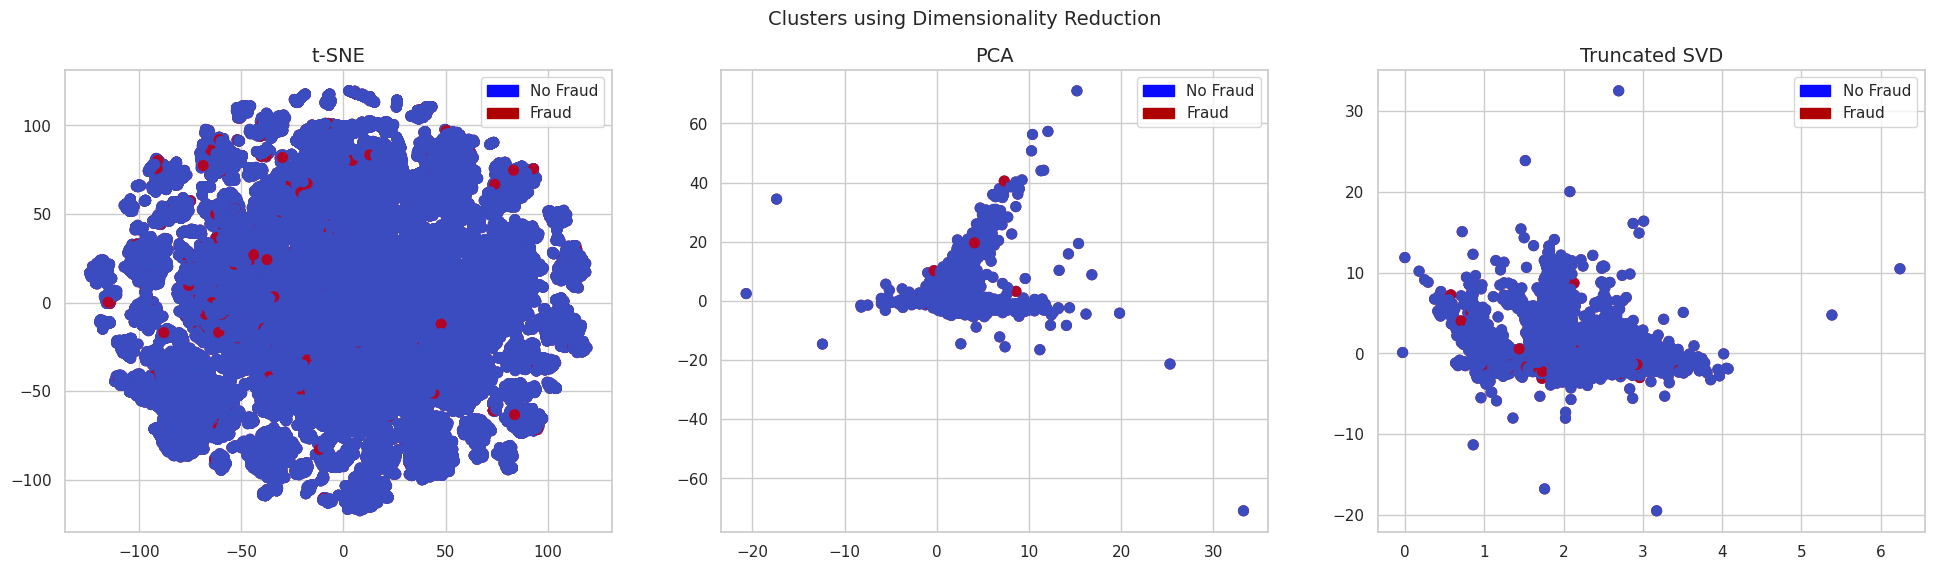

In [113]:
import matplotlib.patches as mpatches

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)
blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='No Default', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Default', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)
ax1.grid(True)
ax1.legend(handles=[blue_patch, red_patch])
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='No Default', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Default', linewidths=2)
ax2.set_title('PCA', fontsize=14)
ax2.grid(True)
ax2.legend(handles=[blue_patch, red_patch])
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='No Default', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Default', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)
ax3.grid(True)
ax3.legend(handles=[blue_patch, red_patch]);

## ***Creating the Submission File*** 

In [115]:
submission = pd.DataFrame({
    'account_number': account_numbers,
    'predicted_probability': model.predict(tfdf.keras.pd_dataframe_to_tf_dataset(df_test), verbose=0)[:,0]
})

submission.to_csv('submission_final.csv', index=False)

print("Submission file created successfully.")

Submission file created successfully.


## ***Sanity Checking***

In [119]:
submission[(submission['predicted_probability'] > 1) | (submission['predicted_probability'] < 0)].shape

(0, 2)